In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc
from imblearn.over_sampling import SMOTE
import tabula


In [44]:
df = pd.read_csv("credit_dataset_5000_enhanced_final.csv")



In [45]:
print(df.head())



   Age  Income  Coapplicant_Income  Dependents  Employ_Status   Debt  \
0   61   26587               10296           1       Employed  56824   
1   36   23236               13264           3  Self-employed  78620   
2   66   19245               32648           5       Employed  34596   
3   29   64148               19563           1       Employed  59612   
4   43  101424               49221           1     Unemployed   1523   

   PrevLDefault  CIBIL_Score  Loan_Approval  
0             1          465              0  
1             1          456              1  
2             0          572              0  
3             0          620              0  
4             0          659              0  


In [46]:
df["Loan_Approval"] = (
    (df["CIBIL_Score"] > 600) & 
    (df["Debt"] < df["Income"]) & 
    (df["PrevLDefault"] == 0)
).astype(int)

In [47]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["Employ_Status"] = le.fit_transform(df["Employ_Status"])

In [48]:
X = df.drop("Loan_Approval", axis=1)
y = df["Loan_Approval"]

In [49]:
print("Class distribution:")
print(y.value_counts())
print("Percentage:")
print(y.value_counts(normalize=True) * 100)

Class distribution:
Loan_Approval
0    4273
1     727
Name: count, dtype: int64
Percentage:
Loan_Approval
0    85.46
1    14.54
Name: proportion, dtype: float64


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)
print("Resampled training distribution:\n", pd.Series(y_train_res).value_counts())

Resampled training distribution:
 Loan_Approval
1    2991
0    2991
Name: count, dtype: int64


In [59]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,        
    max_depth=20,          
    min_samples_split=5,   
    min_samples_leaf=2,      
    random_state=42,
    class_weight="balanced",
    bootstrap=True
)

rf.fit(X_train_res, y_train_res)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [ ]:
from sklearn.model_selection import GridSearchCV


param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}
rf_base = RandomForestClassifier(random_state=42, class_weight="balanced")

grid_search = GridSearchCV(estimator=rf_base, param_grid=param_grid, 
                          cv=3, n_jobs=-1, verbose=2, scoring='accuracy')


grid_search.fit(X_train, y_train)


print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validation accuracy: {:.2f}".format(grid_search.best_score_))


best_rf = grid_search.best_estimator_


y_pred_tuned = best_rf.predict(X_test)

tuned_accuracy = accuracy_score(y_test, y_pred_tuned)
print("Tuned Test Accuracy: {:.2f}%".format(tuned_accuracy * 100))

Fitting 3 folds for each of 216 candidates, totalling 648 fits
Best parameters found:  {'bootstrap': False, 'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best cross-validation accuracy: 0.99
Tuned Test Accuracy: 99.33%


In [53]:
y_pred = rf.predict(X_test)

In [54]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Test Accuracy:", accuracy)

Test Accuracy: 0.9866666666666667


In [55]:
print("Train Accuracy:", accuracy_score(y_train, rf.predict(X_train)))
print("Test Accuracy:", accuracy_score(y_test, rf.predict(X_test)))

Train Accuracy: 0.9985714285714286
Test Accuracy: 0.9866666666666667


In [56]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='accuracy')
print("Cross-validation scores:", cv_scores)
print("Mean CV accuracy:", cv_scores.mean())

Cross-validation scores: [0.98714286 0.98571429 0.99571429 0.98714286 0.99      ]
Mean CV accuracy: 0.9891428571428571


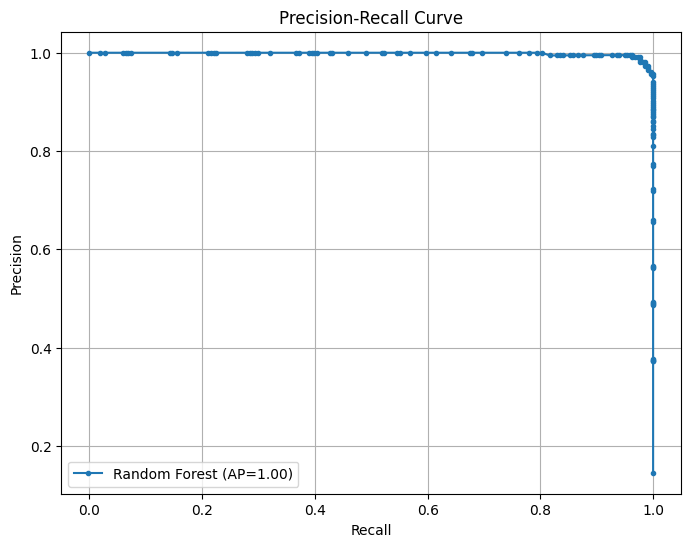


Classification report at threshold=0.4:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      1282
           1       0.94      1.00      0.97       218

    accuracy                           0.99      1500
   macro avg       0.97      0.99      0.98      1500
weighted avg       0.99      0.99      0.99      1500

Confusion Matrix:
 [[1268   14]
 [   0  218]]


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

y_proba = best_rf.predict_proba(X_test)[:, 1]


precision, recall, thresholds = precision_recall_curve(y_test, y_proba)


avg_precision = average_precision_score(y_test, y_proba)

plt.figure(figsize=(8,6))
plt.plot(recall, precision, marker='.', label=f'Random Forest (AP={avg_precision:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.show()

threshold = 0.4
y_pred_thresh = (y_proba >= threshold).astype(int)

from sklearn.metrics import classification_report, confusion_matrix
print(f"\nClassification report at threshold={threshold}:")
print(classification_report(y_test, y_pred_thresh))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_thresh))
